## Objective
To develop and train CNN models with CIFAR10 dataset.CIFAR10 dataset is a collection of images of 10 different animals. Each image is of 32x32 pixel and in R G B scale.

Total images in the dataset = 60000 with 10 animal classes
Each image is of 32 X 32 X 3
*   Train Images:50000
*   Test Images:10000

Here, we will build different CNN models and evaluate them. We will build some CNN model from scratch, and we will also build some CNN model leveraging VGG16.

### What is VGG16
VGG16 is a Convolutional Neural Network (CNN) architecture developed by the Visual Geometry Group (VGG) at the University of Oxford in 2014.

We will use **VGG16** pre-trained CNN model from ImageNet to build our model.

**Pre-trained models available in Keras.io.**
https://keras.io/api/applications/

#### Imagenet
https://image-net.org/about.php

ImageNet runs competition every year for organization to come and present their CNN models. **VGG16** is from the year 2014. It has its pre-defined images that they provide to the teams to use to build the models.

#### VGG16
![VGG16](https://viso.ai/wp-content/uploads/2021/10/vgg-neural-network-architecture.png)

In our model, we will make use of first 3 blocks from VGG16 and transfer the model from it. And then add our own dense layers.

In [4]:
# ===========================
# 1) Imports
# ===========================
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd

from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.applications import VGG16

# ===========================
# 2) Load CIFAR-10 dataset
# ===========================
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalization: Normalize the image pixel values (0-255 -> 0-1)
x_train, x_test = x_train / 255.0, x_test / 255.0

# Normalization: Convert labels to categorical (10 classes)
## It does one-hot encoded vectorization
num_classes = 10
# print(y_train[0])
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_test  = tf.keras.utils.to_categorical(y_test, num_classes)
# print(y_test[0])

# Train/Validation split (80:20 ratio)
from sklearn.model_selection import train_test_split
x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train, test_size=0.2, random_state=42
)

print("Train:", x_train.shape, "Validation:", x_val.shape, "Test:", x_test.shape)


Train: (40000, 32, 32, 3) Validation: (10000, 32, 32, 3) Test: (10000, 32, 32, 3)


In [5]:
# ===========================
# 3) Model Builder Functions
# ===========================

# A simple CNN model
def build_simple_cnn(input_shape=(32,32,3), num_classes=10):
    model = models.Sequential([
        # layer1: Convolutional layer
        layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D(pool_size=(2,2)),

        # layer2: Convolutional layer
        layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
        layers.MaxPooling2D(pool_size=(2,2)),

        # Flattening 2D array to 1D array
        layers.Flatten(),

        # layer3: ANN Hidden layer
        layers.Dense(256, activation='relu'),

        # layer4: ANN Output layer
        layers.Dense(num_classes, activation='softmax')
    ])

    model = compile_model(model)
    return model

# A CNN model with dropout and additional convolutional layer (it addresses overfitting)
def build_dropout_cnn(input_shape=(32,32,3), num_classes=10):
    model = models.Sequential([
        # layer1: Convolutional layer
        layers.Conv2D(filters=32, kernel_size=(3,3), input_shape=input_shape),
        layers.LeakyReLU(alpha=0.1),
        layers.MaxPooling2D(pool_size=(2,2)),

        # layer2: Convolutional layer
        layers.Conv2D(filters=64, kernel_size=(3,3)),
        layers.LeakyReLU(alpha=0.1),
        layers.MaxPooling2D(pool_size=(2,2)),

        # layer3: Convolutional layer
        layers.Conv2D(filters=128, kernel_size=(5,5)),
        layers.LeakyReLU(alpha=0.1),
        layers.MaxPooling2D(pool_size=(2,2)),

        # Flattening 2D array to 1D array
        layers.Flatten(),

        # layer4: ANN Hidden layer
        layers.Dense(256),
        layers.LeakyReLU(alpha=0.1),
        layers.Dropout(0.5),

        # layer5: ANN Output layer
        layers.Dense(num_classes, activation='softmax')
    ])

    model = compile_model(model)
    return model

# ===========================
#### Below models are using Transfer Learning Technique
#### Using pre-trained VGG16 model

# ===========================
# VGG16 Feature Extraction Model.
## - Leverage convolutional layers of the base model for feature extraction
## - All pretrained VGG16 layers are frozen → weights won’t change during training.
## - You’re only using VGG16 as a fixed feature extractor.
## - You take the output from block3_pool.
## - Add your Dense and Classifier layer, and train them. (You only train the layers you add. do not train the VGG16 layers)
##
## - Faster training since feature extraction is already done.
## - Low risk of overfitting
# ===========================
def build_vgg16_feature_extraction(input_shape=(32,32,3), num_classes=10):
    """
    VGG16 model with frozen base layers for feature extraction.
    """
    # use imagenet features from imagenet dataset. (imagenet is dataset of 1000 classes and it includes classes of CIFAR10. Hence, we can leverage its weight.)
    base_model = VGG16(weights='imagenet',
                       include_top=False,
                       input_shape=input_shape,
                       pooling='max')
    base_model.trainable = False  # Freeze base model
    base_model.summary()

    # From the base model, only pickup the convolutional layers upto the layer called "block3_pool"
    ## See the VGG16 CNN layers from base_model.summary() to understand
    transfer_layer = models.Model(
      inputs=base_model.input,
      outputs=base_model.get_layer('block3_pool').output
    )

    model = models.Sequential([
        transfer_layer, #base model layers is the starting point
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    model = compile_model(model)
    return model

# ===========================
# VGG16 Fine-Tunning
## In this approach, you use all the layers from VGG16
## You unfreeze a few layers from VGG16.
##
## In this case, you unfreeze layers after layer 15. (it means all layers after 15 are re-trained)
## You add your dense and classifier layer
# ===========================
def build_vgg16_fine_tuning(input_shape=(32,32,3), num_classes=10, fine_tune_at=15):
    """
    VGG16 model with some base layers unfrozen for fine-tuning.

    Parameters:
    - fine_tune_at: layer index from which to start training the base model
    """
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = True  # Unfreeze all layers

    # Freeze layers up to fine_tune_at
    for layer in base_model.layers[:fine_tune_at]:
        layer.trainable = False

    model = models.Sequential([
        base_model,
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    model = compile_model(model)
    return model

# Compile the model
def compile_model(model,
                  learning_rate=0.0005,
                  loss='categorical_crossentropy',
                  metrics=['accuracy']):
    """
    Compiles a given Keras model with common settings.
    """
    optimizer = optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer,
                  loss=loss,
                  metrics=metrics)
    print(model.summary())
    return model

# ===========================
# 4) Callbacks Function
# ===========================
def get_callbacks(model_name):
    return [
        callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(factor=0.2, patience=3),
        callbacks.ModelCheckpoint(f"{model_name}.h5", save_best_only=True)
    ]

In [6]:
# ===========================
# 5) Train and Evaluate Multiple Models
# ===========================
models_to_train = {
    "simple_cnn": build_simple_cnn,
    "dropout_cnn": build_dropout_cnn,
    "vgg16_feature_extraction": build_vgg16_feature_extraction,
    "vgg16_fine_tuning": build_vgg16_fine_tuning,
}

results = []

for name, build_fn in models_to_train.items():
    print(f"\n=== Training {name} ===")
    model = build_fn(input_shape=(32,32,3), num_classes=num_classes)
    history = model.fit(
        x_train, y_train,
        # validation_data=(x_val, y_val),
        validation_split=0.1,
        epochs=15,
        batch_size=128,
        callbacks=get_callbacks(name),
        verbose=2
    )

    # Evaluate on train and test sets
    train_loss, train_acc = model.evaluate(x_train, y_train, verbose=0)
    test_loss, test_acc   = model.evaluate(x_test, y_test, verbose=0)

    print(f"{name} Train Accuracy: {train_acc:.4f}, Test Accuracy: {test_acc:.4f}")

    results.append({
        "model": name,
        "train_accuracy": train_acc,
        "train_loss": train_loss,
        "test_accuracy": test_acc,
        "test_loss": test_loss,
        "history": history
    })



=== Training simple_cnn ===


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 612,042 (2.33 MB)

 Trainable params: 612,042 (2.33 MB)

...

None
Epoch 1/15


282/282 - 19s - 68ms/step - accuracy: 0.5871 - loss: 1.1996 - val_accuracy: 0.6898 - val_loss: 0.9076 - learning_rate: 5.0000e-04
Epoch 2/15


282/282 - 9s - 33ms/step - accuracy: 0.7090 - loss: 0.8628 - val_accuracy: 0.7048 - val_loss: 0.8614 - learning_rate: 5.0000e-04
Epoch 3/15


282/282 - 10s - 37ms/step - accuracy: 0.7514 - loss: 0.7339 - val_accuracy: 0.7110 - val_loss: 0.8589 - learning_rate: 5.0000e-04
Epoch 4/15


282/282 - 10s - 34ms/step - accuracy: 0.7859 - loss: 0.6288 - val_accuracy: 0.7297 - val_loss: 0.8163 - learning_rate: 5.0000e-04
Epoch 5/15
282/282 - 10s - 34ms/step - accuracy: 0.8128 - loss: 0.5447 - val_accuracy: 0.7368 - val_loss: 0.8478 - learning_rate: 5.0000e-04
Epoch 6/15
282/282 - 10s - 34ms/step - accuracy: 0.8393 - loss: 0.4651 - val_accuracy: 0.7405 - val_loss: 0.8273 - learning_rate: 5.0000e-04
Epoch 7/15
282/282 - 9s - 32ms/step - accuracy: 0.8647 - loss: 0.3945 - val_accuracy: 0.7362 - val_loss: 0.9068 - learning_rate: 5.0000e-04
Epoch 8/15
282/282 - 10s - 37ms/step - accuracy: 0.9352 - loss: 0.1945 - val_accuracy: 0.7525 - val_loss: 0.9836 - learning_rate: 1.0000e-04
Epoch 9/15
282/282 - 9s - 31ms/step - accuracy: 0.9593 - loss: 0.1236 - val_accuracy: 0.7550 - val_loss: 1.1419 - learning_rate: 1.0000e-04
vgg16_fine_tuning Train Accuracy: 0.8242, Test Accuracy: 0.7353



Model Metrics Comparison:
                      Model  Train Accuracy  Train Loss  Val Accuracy  \
0                simple_cnn        0.788000    0.621080       0.69275   
1               dropout_cnn        0.837556    0.480540       0.70400   
2  vgg16_feature_extraction        0.744111    0.745994       0.74700   
3         vgg16_fine_tuning        0.959333    0.123558       0.75500   

   Val Loss  Test Accuracy  Test Loss  
0  0.931972         0.6919   0.920299  
1  0.902976         0.7125   0.874340  
2  0.811837         0.7426   0.800040  
3  1.141851         0.7353   0.797505  


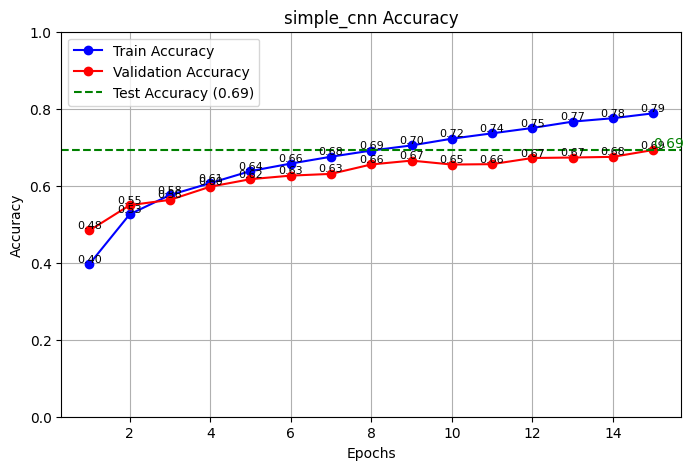

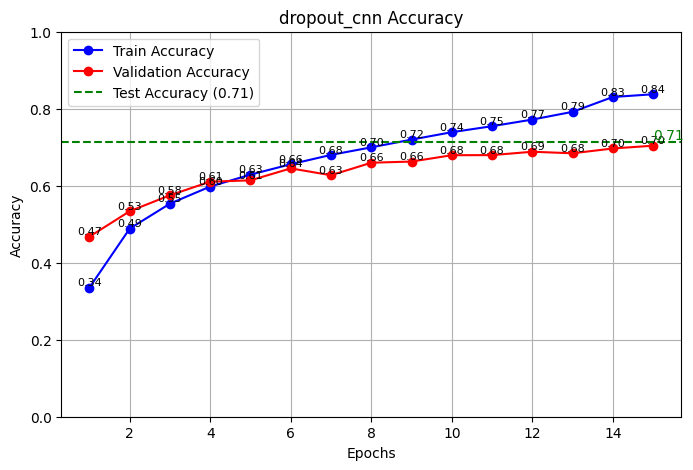

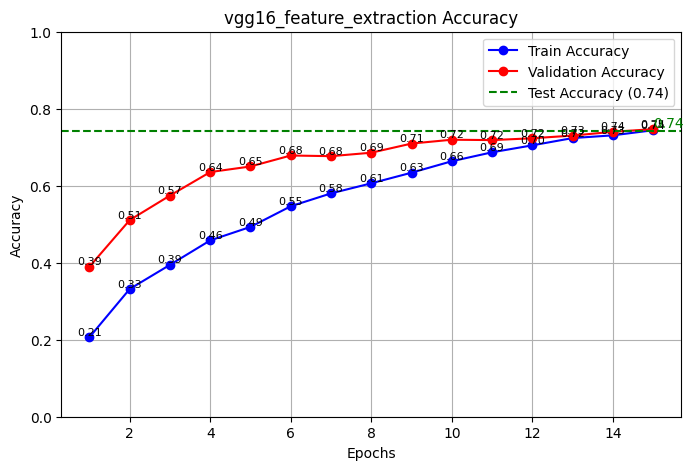

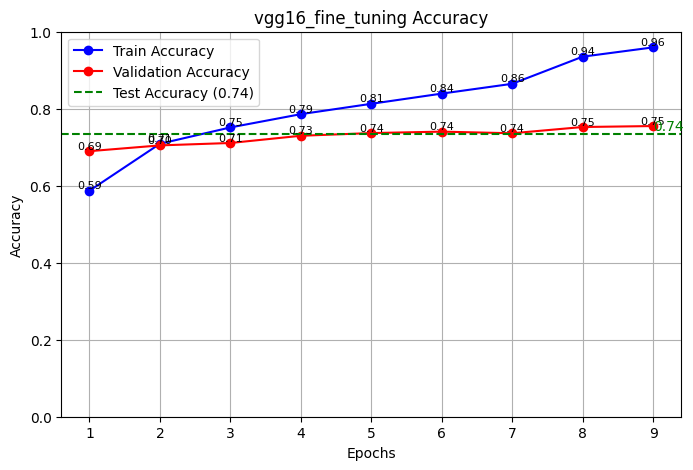

In [7]:
# ===========================
# 6) Compare Models and Plot
# ===========================
comparison_data = []

for r in results:
    history = r["history"].history
    train_acc = history["accuracy"][-1]
    train_loss = history["loss"][-1]
    val_acc = history["val_accuracy"][-1]
    val_loss = history["val_loss"][-1]
    test_acc = r["test_accuracy"]
    test_loss = r["test_loss"]

    comparison_data.append({
        "Model": r["model"],
        "Train Accuracy": train_acc,
        "Train Loss": train_loss,
        "Val Accuracy": val_acc,
        "Val Loss": val_loss,
        "Test Accuracy": test_acc,
        "Test Loss": test_loss
    })

df_full_results = pd.DataFrame(comparison_data)
print("\nModel Metrics Comparison:")
print(df_full_results)

# ===========================
# Plot train, val, and test accuracy with datapoint values
# ===========================
for r in results:
    history = r["history"].history
    epochs = range(1, len(history["accuracy"]) + 1)
    test_acc = r["test_accuracy"]

    plt.figure(figsize=(8,5))

    # Train Accuracy
    plt.plot(epochs, history["accuracy"], 'bo-', label="Train Accuracy")
    for x, y in zip(epochs, history["accuracy"]):
        plt.text(x, y, f"{y:.2f}", fontsize=8, ha='center', va='bottom')

    # Validation Accuracy
    plt.plot(epochs, history["val_accuracy"], 'ro-', label="Validation Accuracy")
    for x, y in zip(epochs, history["val_accuracy"]):
        plt.text(x, y, f"{y:.2f}", fontsize=8, ha='center', va='bottom')

    # Test Accuracy as horizontal line
    plt.axhline(y=test_acc, color='g', linestyle='--', label=f"Test Accuracy ({test_acc:.2f})")
    plt.text(epochs[-1], test_acc, f"{test_acc:.2f}", color='g', fontsize=10, ha='left', va='bottom')

    plt.title(f"{r['model']} Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(True)
    plt.show()
